import libraries

In [2]:
# ==========================================
# IMPORTING LIBRARIES
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("customer churn.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
# First 5 Rows
df.head()

,Customer_ID,Age,Gender,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Online_Security,Tech_Support,Streaming_TV,Streaming_Movies,Payment_Method,Paperless_Billing,Num_Complaints,Satisfaction_Score,Support_Calls,Late_Payments,Avg_Monthly_Usage_GB,Churn_Status
0,CUST000000,56.0,Female,67.0,74.32,6537.44,One Year,Fiber,Yes,No,NaN,Yes,UPI,No,0.0,2.0,5.0,4.0,227.5,At Risk
1,CUST000001,69.0,Male,90.0,118.90,17141.31,One Year,NaN,No,NaN,No,No,UPI,No,8.0,3.0,8.0,11.0,313.1,Churned
2,CUST000002,NaN,Male,83.0,NaN,8110.30,Month-to-Month,NaN,Yes,No,No,No,E-Wallet,No,1.0,2.0,14.0,3.0,318.3,Churned
3,CUST000003,32.0,Female,103.0,186.18,1281.63,Month-to-Month,DSL,No,Yes,Yes,Yes,UPI,NaN,10.0,3.0,1.0,1.0,67.6,Churned
4,CUST000004,60.0,Male,106.0,183.14,NaN,Two Year,DSL,No,No,NaN,No,Bank Transfer,NaN,5.0,9.0,6.0,12.0,59.5,Churned


In [5]:
# Last 5 Rows
df.tail()

,Customer_ID,Age,Gender,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Online_Security,Tech_Support,Streaming_TV,Streaming_Movies,Payment_Method,Paperless_Billing,Num_Complaints,Satisfaction_Score,Support_Calls,Late_Payments,Avg_Monthly_Usage_GB,Churn_Status
99995,CUST007217,73.0,Female,16.0,NaN,10343.85,NaN,Fiber,No,Yes,No,Yes,Bank Transfer,Yes,6.0,3.0,8.0,6.0,440.8,Churned
99996,CUST047635,59.0,Male,NaN,64.44,9788.35,One Year,Fiber,Yes,Yes,No,No,UPI,Yes,NaN,9.0,13.0,6.0,498.7,Churned
99997,CUST009509,41.0,Female,118.0,95.95,12180.69,One Year,Fiber,Yes,No,Yes,Yes,Bank Transfer,Yes,7.0,4.0,12.0,8.0,65.3,Churned
99998,CUST072517,64.0,Female,75.0,64.93,2070.07,Two Year,Fiber,Yes,No,No,No,Bank Transfer,No,6.0,9.0,2.0,10.0,57.2,At Risk
99999,CUST033711,68.0,Female,100.0,76.42,8150.40,One Year,Fiber,Yes,No,Yes,Yes,Credit Card,No,8.0,5.0,2.0,12.0,422.9,Churned


In [6]:
# Number of Rows and Columns

print("Shape of Dataset :", df.shape)

print("Number of Rows :", df.shape[0])

print("Number of Columns :", df.shape[1])

Shape of Dataset : (100000, 20)
Number of Rows : 100000
Number of Columns : 20


In [7]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Customer_ID           100000 non-null  object 
 1   Age                   95000 non-null   float64
 2   Gender                95000 non-null   object 
 3   Tenure_Months         95000 non-null   float64
 4   Monthly_Charges       95000 non-null   float64
 5   Total_Charges         95000 non-null   float64
 6   Contract_Type         95000 non-null   object 
 7   Internet_Service      63195 non-null   object 
 8   Online_Security       95000 non-null   object 
 9   Tech_Support          95000 non-null   object 
 10  Streaming_TV          95000 non-null   object 
 11  Streaming_Movies      95000 non-null   object 
 12  Payment_Method        95000 non-null   object 
 13  Paperless_Billing     95000 non-null   object 
 14  Num_Complaints        95000 non-null   float64
 15  S

In [8]:
# Missing Values

missing_values = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': round((df.isnull().sum()/len(df))*100,2)
})

missing_values[missing_values['Missing Count'] > 0]

,Missing Count,Missing Percentage
Age,5000,5.0
Gender,5000,5.0
Tenure_Months,5000,5.0
Monthly_Charges,5000,5.0
Total_Charges,5000,5.0
Contract_Type,5000,5.0
Internet_Service,36805,36.8
Online_Security,5000,5.0
Tech_Support,5000,5.0
Streaming_TV,5000,5.0


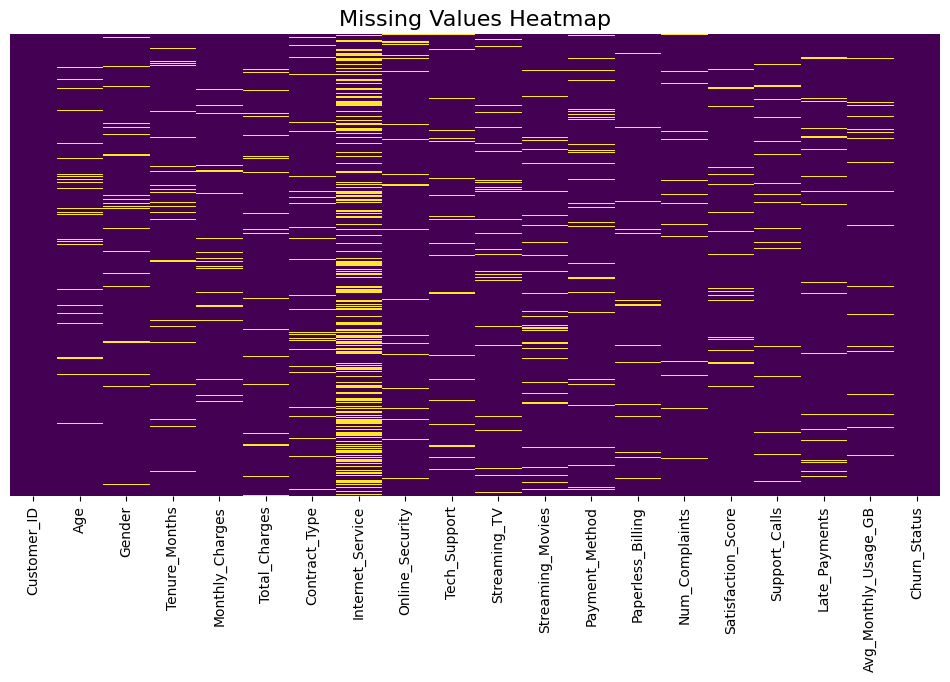

In [9]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap",fontsize=16)
plt.show()

In [10]:
duplicates = df.duplicated().sum()

print("Total Duplicate Rows :", duplicates)

Total Duplicate Rows : 388


In [11]:
df['Churn_Status'].value_counts()

Churn_Status
Churned     59731
Retained    21143
At Risk     19126
Name: count, dtype: int64

In [12]:
df['Churn_Status'].value_counts(normalize=True)*100

Churn_Status
Churned     59.731
Retained    21.143
At Risk     19.126
Name: proportion, dtype: float64

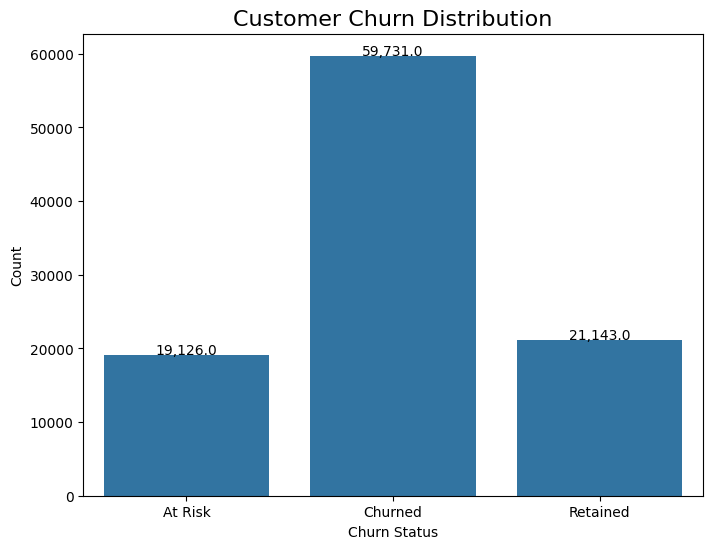

In [13]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df,
    x='Churn_Status'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,}',
        (p.get_x()+0.25,p.get_height()+100)
    )

plt.title("Customer Churn Distribution",fontsize=16)
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.show()

In [14]:
numerical_cols = df.select_dtypes(
    include=['int64','float64']
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

Numerical Columns
['Age', 'Tenure_Months', 'Monthly_Charges', 'Total_Charges', 'Num_Complaints', 'Satisfaction_Score', 'Support_Calls', 'Late_Payments', 'Avg_Monthly_Usage_GB']

Categorical Columns
['Customer_ID', 'Gender', 'Contract_Type', 'Internet_Service', 'Online_Security', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Payment_Method', 'Paperless_Billing', 'Churn_Status']


In [15]:
print("="*50)

print("DATA QUALITY REPORT")

print("="*50)

print(f"Rows              : {df.shape[0]}")
print(f"Columns           : {df.shape[1]}")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"Duplicate Rows    : {df.duplicated().sum()}")

print("="*50)

DATA QUALITY REPORT
Rows              : 100000
Columns           : 20
Missing Values    : 121805
Duplicate Rows    : 388


In [16]:
# Create Backup

df1 = df.copy()

print("Backup Created Successfully")

Backup Created Successfully


In [17]:
print("Before Removing Duplicates :", df1.shape)

df1.drop_duplicates(inplace=True)

print("After Removing Duplicates :", df1.shape)

Before Removing Duplicates : (100000, 20)
After Removing Duplicates : (99612, 20)


In [18]:
num_cols = df1.select_dtypes(
    include=['int64','float64']
).columns

for col in num_cols:
    df1[col].fillna(df1[col].median(), inplace=True)

In [19]:
cat_cols = df1.select_dtypes(
    include='object'
).columns

for col in cat_cols:
    df1[col].fillna(df1[col].mode()[0], inplace=True)

In [20]:
df1.isnull().sum().sum()

np.int64(0)

In [21]:
df1.drop('Customer_ID', axis=1, inplace=True)

df1.head()

,Age,Gender,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Online_Security,Tech_Support,Streaming_TV,Streaming_Movies,Payment_Method,Paperless_Billing,Num_Complaints,Satisfaction_Score,Support_Calls,Late_Payments,Avg_Monthly_Usage_GB,Churn_Status
0,56.0,Female,67.0,74.32,6537.44,One Year,Fiber,Yes,No,Yes,Yes,UPI,No,0.0,2.0,5.0,4.0,227.5,At Risk
1,69.0,Male,90.0,118.90,17141.31,One Year,DSL,No,Yes,No,No,UPI,No,8.0,3.0,8.0,11.0,313.1,Churned
2,46.0,Male,83.0,105.20,8110.30,Month-to-Month,DSL,Yes,No,No,No,E-Wallet,No,1.0,2.0,14.0,3.0,318.3,Churned
3,32.0,Female,103.0,186.18,1281.63,Month-to-Month,DSL,No,Yes,Yes,Yes,UPI,No,10.0,3.0,1.0,1.0,67.6,Churned
4,60.0,Male,106.0,183.14,10027.78,Two Year,DSL,No,No,Yes,No,Bank Transfer,No,5.0,9.0,6.0,12.0,59.5,Churned


In [22]:
X = df1.drop('Churn_Status', axis=1)

y = df1['Churn_Status']

In [23]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['At Risk' 'Churned' 'Retained']


In [24]:
X.select_dtypes(include='object').columns

Index(['Gender', 'Contract_Type', 'Internet_Service', 'Online_Security',
       'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Payment_Method',
       'Paperless_Billing'],
      dtype='object')

In [25]:
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

X.head()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Num_Complaints,Satisfaction_Score,Support_Calls,Late_Payments,Avg_Monthly_Usage_GB,Gender_Male,Contract_Type_One Year,Contract_Type_Two Year,Internet_Service_Fiber,Online_Security_Yes,Tech_Support_Yes,Streaming_TV_Yes,Streaming_Movies_Yes,Payment_Method_Credit Card,Payment_Method_E-Wallet,Payment_Method_UPI,Paperless_Billing_Yes
0,56.0,67.0,74.32,6537.44,0.0,2.0,5.0,4.0,227.5,0,1,0,1,1,0,1,1,0,0,1,0
1,69.0,90.0,118.90,17141.31,8.0,3.0,8.0,11.0,313.1,1,1,0,0,0,1,0,0,0,0,1,0
2,46.0,83.0,105.20,8110.30,1.0,2.0,14.0,3.0,318.3,1,0,0,0,1,0,0,0,0,1,0,0
3,32.0,103.0,186.18,1281.63,10.0,3.0,1.0,1.0,67.6,0,0,0,0,0,1,1,1,0,0,1,0
4,60.0,106.0,183.14,10027.78,5.0,9.0,6.0,12.0,59.5,1,0,1,0,0,0,1,0,0,0,0,0


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)
print("y Train :", y_train.shape)
print("y Test  :", y_test.shape)

X Train : (79689, 21)
X Test  : (19923, 21)
y Train : (79689,)
y Test  : (19923,)


In [28]:
pd.Series(y_train).value_counts(normalize=True)*100

1    59.722170
2    21.161013
0    19.116817
Name: proportion, dtype: float64

In [29]:
pd.Series(y_test).value_counts(normalize=True)*100

1    59.724941
2    21.161472
0    19.113587
Name: proportion, dtype: float64

In [30]:
stratify=y

In [31]:
print("Total Features :", X.shape[1])

Total Features : 21


In [32]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
# Create Model

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Train Model

lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [35]:
# Prediction on Test Data

y_pred_lr = lr_model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 93.39 %


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      3808
           1       0.96      0.97      0.97     11899
           2       0.93      0.92      0.93      4216

    accuracy                           0.93     19923
   macro avg       0.91      0.91      0.91     19923
weighted avg       0.93      0.93      0.93     19923



In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

cm

array([[ 3166,   386,   256],
       [  329, 11546,    24],
       [  261,    61,  3894]])

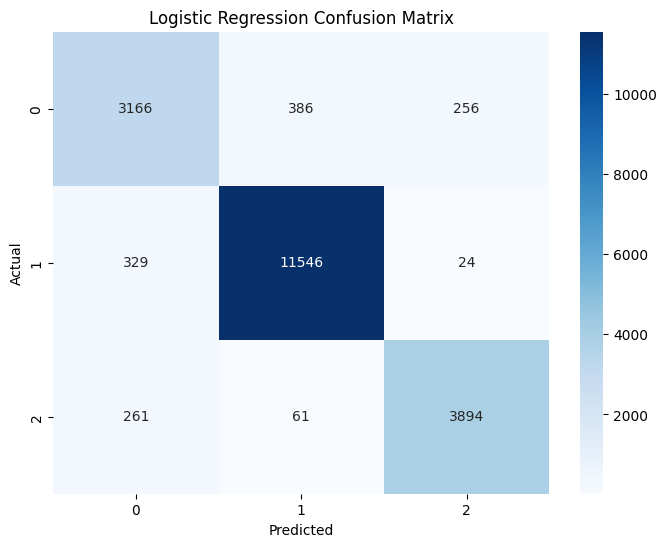

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
# Create Model

dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train Model

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [42]:
# Predict Test Data

y_pred_dt = dt_model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy :", round(dt_accuracy*100,2), "%")

Decision Tree Accuracy : 82.98 %


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.59      0.58      0.59      3808
           1       0.91      0.91      0.91     11899
           2       0.81      0.82      0.81      4216

    accuracy                           0.83     19923
   macro avg       0.77      0.77      0.77     19923
weighted avg       0.83      0.83      0.83     19923



In [45]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

cm_dt

array([[ 2219,   912,   677],
       [  883, 10868,   148],
       [  629,   142,  3445]])

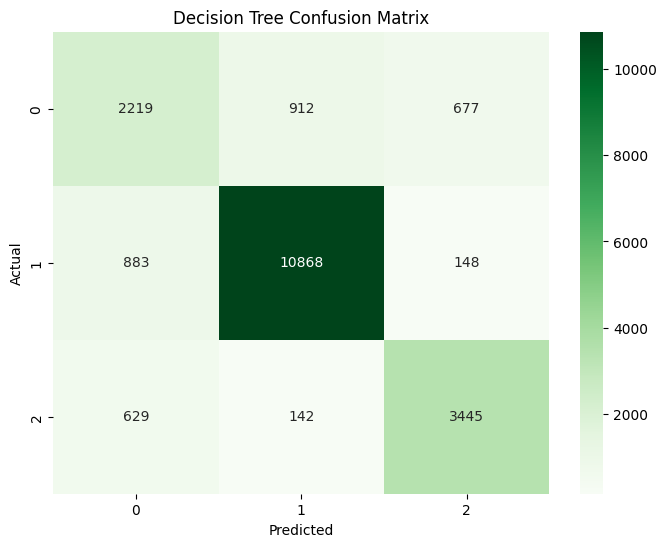

In [46]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
from sklearn.model_selection import cross_val_score

dt_cv = cross_val_score(
    dt_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores :", dt_cv)
print("Mean CV Accuracy :", dt_cv.mean())

Cross Validation Scores : [0.82954374 0.83029664 0.82963558 0.82787873 0.83299869]
Mean CV Accuracy : 0.8300706772373709


In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
# Create Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train Model

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [50]:
# Predict Test Data

y_pred_rf = rf_model.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy :", round(rf_accuracy*100, 2), "%")

Random Forest Accuracy : 88.22 %


In [52]:
import joblib

# Save the top-performing Logistic Regression model
joblib.dump(lr_model, 'churn_lr_model.pkl')

# Save the scaler and encoder for the frontend
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(target_encoder, 'target_encoder.pkl')

['target_encoder.pkl']